<h1>Prosjektoppgave</h1>


Created on Wed Mar 11 2026

author: Magnus Slettjord, magnusslettjord@hotmail.com


support_uke_24.xlsx filen er organisert på følgende måte.

Kolonne 1: Ukedag henvendelsen fant sted

Kolonne 2 : Klokkeslett kunden tok kontakt med supportavdelignen

Kolonne 3: samtalens varighet

Kolonne 4: Kundenstilfredshet, stigende. Ikke komplett

A

In [56]:
import pandas as pd
import numpy as np

uke24 = "support_uke_24.xlsx"  # Leser av filen

data = pd.read_excel(uke24)  # Gjør om dataen til en dataframe

# Lager arrays med informasjonen fra excel-filen
u_dag = data["Ukedag"].values  # henter kolonnen ukedag som en pandas serie, .values konverterer den til et numpy array
kl_slett = data["Klokkeslett"].values # lager array for klokkeslett
varighet= data["Varighet"].values  # lager array for varighet på samtalen
score= data["Tilfredshet"].values  # lager array med score på tilfredshet

B

Et program som finner antallet henvendelser for hver av de 5 ukedagene. 
Resultatet visualiseres via et søylediagram

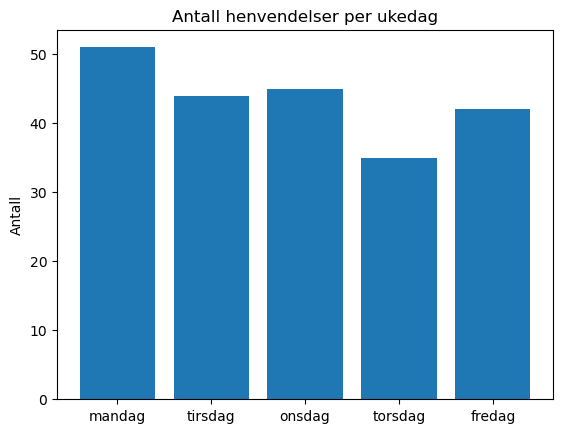

Mandager: 51
Tirsdager: 44
Onsdager: 45
Torsdager: 35
Fredager: 42


In [4]:
import matplotlib.pyplot as plt

# lager variabel for hver av dagene
mandager = 0
tirsdager = 0
onsdager = 0
torsdager = 0
fredager = 0

#for-løkke som øker antallet på hver av varaibelene for hver gang en av dagene gjentas i arrayen u_dag
for dag in u_dag:
    if dag =="Mandag":
        mandager += 1
    if dag =="Tirsdag":
        tirsdager += 1
    if dag =="Onsdag":
        onsdager += 1
    if dag =="Torsdag":
        torsdager += 1
    if dag =="Fredag":
        fredager += 1

# Lister med ukedager og antall
dager = ["mandag", "tirsdag", "onsdag", "torsdag", "fredag"]
antall = [mandager, tirsdager, onsdager, torsdager, fredager]

plt.bar(dager, antall)
plt.ylabel("Antall")
plt.title("Antall henvendelser per ukedag")
plt.show()
print(f'Mandager: {mandager}')
print(f'Tirsdager: {tirsdager}')
print(f'Onsdager: {onsdager}')
print(f'Torsdager: {torsdager}')
print(f'Fredager: {fredager}')

C

Et program som finner minste og lengste samtaletid. 

In [5]:
minste = np.min(varighet)  # finner minste verdien i arrayet varighet
lengste = np.max(varighet) # finner største verdien i arrayet varighet

# benytter split funksjonen for å dele verdiene i lister hvor indeks 0 er timer, 1 er minutter og 2 er sekunder
minst = minste.split(":")
lengst = lengste.split(":")

print (f' Den korteste samtalen som ble registrert var {minst[1]} minutter og {minst[2]} sekunder lang')
print (f' Den lengste samtalen som ble registrert var {lengst[1]} minutter og {lengst[2]} sekunder lang')


 Den korteste samtalen som ble registrert var 00 minutter og 59 sekunder lang
 Den lengste samtalen som ble registrert var 11 minutter og 28 sekunder lang


D

Et program som skriver ut gjennomsnittlig samtaletid baser på alle henvendelser i uke 24

In [6]:
varighet_sekunder = []  # lager et array for lengde i sekunder

# lager en for-løkke som går gjennom arrayet, splitter opp den enkelte strengen i h, m og s. 
# regner det om til sekunder og legger det til det nye arrayet
for tid in varighet:   
    h, m, s = tid.split(":")  
    sekunder = int(h) * 60 * 60 + int (m) * 60 + int(s)  # gjør om tekststreng til integer.
    varighet_sekunder.append(sekunder)  

gjennomsnitt = np.average(varighet_sekunder)  # Regner ut gjennomsnittstiden i sekunder

#Regner om sekundene til timer:minutter:sekunder 
gjennomsnitt_timer = gjennomsnitt // 3600  # heltallsdivisjon gir antall timer
gjennomsnitt_minutt = (gjennomsnitt % 3600) //60  # gir antall minutter av resten fra timene
gjennomsnitt_sekund = gjennomsnitt % 60  # gir resten som ikke gikk inn i minuttene
#skriver ut svaret som heltall med to siffer
print(f'Gjennomsnittlig samtaletid er {int(gjennomsnitt_timer):02}:{int(gjennomsnitt_minutt):02}:{int(gjennomsnitt_sekund):02}')


Gjennomsnittlig samtaletid er 00:06:40


E

Skriv et program som finner det totale antall henvendelser supportavdelingen mottok 
for hver av tidsrommene 08-10, 10-12, 12-14 og 14-16 for uke 24. Resultatet visualiseres ved 
bruk av et sektordiagram 

Henvendelsene fordeler seg som følger:
klokken 08-10: 98 henvendelser
klokken 10-12: 40 henvendelser
klokken 12-14: 45  henvendelser
klokken 14-16: 34 henvendelser


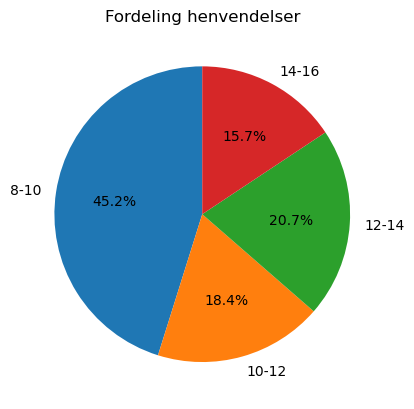

In [74]:
import matplotlib.pyplot as plt

#Variabler for antall henvendelse i hver bolk
bolk_8_10 = 0
bolk_10_12 = 0
bolk_12_14 = 0
bolk_14_16 = 0

#For-løkke som deler opp de enkelte tidspunktene mellom bolkene
for tid in kl_slett:
    h, m, s = tid.split(":")  # deler opp strengen i kl_slett i h, m, og s.
    if 8 <= int(h) < 10:  # sjekker om timeverdien h er mellom klokka 8 og 10
       bolk_8_10 += 1  # legger til en på variabelen for klokka 8-10 bolken. 
    elif 10 <= int(h) < 12:
       bolk_10_12 += 1
    elif 12 <= int(h) < 14:
       bolk_12_14 += 1
    elif 14 <= int(h) < 16:
       bolk_14_16 += 1

#Skriver ut antallet henvendelser fordelt på hver bolk
print(f'Henvendelsene fordeler seg som følger:')
print(f'klokken 08-10: {bolk_8_10} henvendelser')
print(f'klokken 10-12: {bolk_10_12} henvendelser')
print(f'klokken 12-14: {bolk_12_14}  henvendelser')
print(f'klokken 14-16: {bolk_14_16} henvendelser')
     
#Lager sektordiagram
y = np.array([bolk_8_10, bolk_10_12, bolk_12_14, bolk_14_16])  # angir sektorene som de forskjellige bolkene
navn = ["8-10", "10-12", "12-14", "14-16"]  # Navngir de forskjellige sektorene

plt.pie(y, labels=navn, startangle = 90, autopct='%.1f%%')  # skriver ut sektordiagrammet med prosentandel henvendelser
plt.title("Fordeling henvendelser") # Tittel på sektordiagrammet
plt.show()

F

Lag et program som regner ut supportavdelings NPS og skriver svaret til skjerm. Merk: 
Kunder som ikke har gitt tilbakemelding på tilfredshet, skal utelates fra utregningene. 

In [79]:
#Lager variabler for å telle opp antallet positive, negative, nøytrale, og urapporterte svar.
promoters = 0
detractors = 0
passives = 0
nan_antall = 0

#Lager en for-løkke for å gå gjennom arrayet score fra oppgave A. 
for resultat in score:
    if np.isnan(resultat): # Teller antallet verdier som er "not a number"
        nan_antall += 1 
    elif 1 <= resultat < 7: # Teller antallet med score under 7 som negativ
        detractors += 1
    elif 7 <= resultat <9:  # Teller antallet med score 7-8 som nøytrale
        passives += 1
    elif 9 <= resultat <= 10:  # Teller antallet med score 9-10 som positive
        promoters +=1
    
antall_svar = promoters + detractors + passives  # Regner sammen antallet svar som ikke er "not a number"
NPS = (promoters / antall_svar * 100 ) - (detractors / antall_svar * 100)  # regner ut NPS ved å trekke negativ fra positiv andel
print(f' Supportavdelingens NPS er {NPS:.0f}') # skriver ut svaret uten decimaler som presentert i oppgaven


 Supportavdelingens NPS er 42
